# Isolation Forest Analysis

This notebook analyzes the Isolation Forest anomaly detector results for the financial instruments in the project.

It is designed to work with the files created by your pipeline:

- `data/processed/market_data_features_2021_2026.csv`
- `data/processed/isolation_forest_results.csv`
- `results/tables/isolation_forest_summary.csv`

## Notebook goals

This notebook provides:

1. Data loading and validation
2. Isolation Forest summary analysis
3. Visual inspection of:
   - price series
   - trading volume
   - rolling return statistics
   - rolling volatility
   - Isolation Forest anomaly scores
   - detected anomalies
4. Ticker-level deep dives
5. Identification of the most extreme anomaly dates
6. Optional export of report-ready figures

This notebook focuses only on the Isolation Forest model itself.
Model comparisons can be done later in a separate notebook.


## 1. Imports

In [78]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 2. Configuration

In [79]:
STOCK_SERIES = ["AMD", "HIMS", "ORCL"]
INDEX_SERIES = ["SP500", "NASDAQ", "VIX"]
SERIES_TO_RUN = STOCK_SERIES + INDEX_SERIES

EVENT_GAP_BARS = 3
VOLUME_STYLE = "line"

SERIES_TO_RUN


['AMD', 'HIMS', 'ORCL', 'SP500', 'NASDAQ', 'VIX']

## 3. File paths

In [83]:
PROJECT_ROOT = Path(r"G:\My Drive\MSc. in Data Science\S4 Project in Data Science\project")

FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "market_data_features_2021_2026.csv"
RESULTS_PATH = PROJECT_ROOT / "data" / "processed" / "isolation_forest_results.csv"
SUMMARY_PATH = PROJECT_ROOT / "results" / "tables" / "isolation_forest_summary.csv"

OUTPUT_DIR = PROJECT_ROOT / "results" / "notebooks" / "isolation_forest_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUBSET_RESULTS_PATH = OUTPUT_DIR / "isolation_forest_results_selected.csv"
SUBSET_SUMMARY_PATH = OUTPUT_DIR / "isolation_forest_summary_selected.csv"

assert FEATURES_PATH.exists(), f"Missing file: {FEATURES_PATH}"
assert RESULTS_PATH.exists(), f"Missing file: {RESULTS_PATH}"
assert SUMMARY_PATH.exists(), f"Missing file: {SUMMARY_PATH}"

FEATURES_PATH, RESULTS_PATH, SUMMARY_PATH

(WindowsPath('G:/My Drive/MSc. in Data Science/S4 Project in Data Science/project/data/processed/market_data_features_2021_2026.csv'),
 WindowsPath('G:/My Drive/MSc. in Data Science/S4 Project in Data Science/project/data/processed/isolation_forest_results.csv'),
 WindowsPath('G:/My Drive/MSc. in Data Science/S4 Project in Data Science/project/results/tables/isolation_forest_summary.csv'))

## 4. Load datasets

In [84]:
features_df = pd.read_csv(FEATURES_PATH, parse_dates=["Date"], low_memory=False)
iforest_df = pd.read_csv(RESULTS_PATH, parse_dates=["Date"], low_memory=False)
summary_raw_df = pd.read_csv(SUMMARY_PATH, low_memory=False)

print("Features shape:", features_df.shape)
print("Isolation Forest results shape:", iforest_df.shape)
print("Raw summary shape:", summary_raw_df.shape)

display(features_df.head())
display(iforest_df.head())


Features shape: (19770, 74)
Isolation Forest results shape: (19770, 55)
Raw summary shape: (15, 8)


,Date,SeriesName,Ticker,AssetType,Sector,Industry,Exchange,Currency,Open,High,Low,Close,Adj Close,Volume,Price,simple_return,abs_simple_return,log_return,abs_log_return,return_5d,return_10d,return_20d,z_simple_return_20,z_return_20,hl_range_pct,oc_change_pct,gap_pct,body_to_range,upper_shadow_pct,lower_shadow_pct,range_expansion_20,ma_5,ma_20,ma_60,dist_ma_20,dist_ma_60,ma_spread_5_20,vol_5,vol_20,vol_60,simple_vol_5,simple_vol_20,simple_vol_60,vol_ratio_5_20,log_volume,volume_change,volume_z_20,relative_volume_20,dollar_volume,SP500_level,SP500_simple_return,SP500_log_return,SP500_simple_vol_20,SP500_vol_20,SP500_z_simple_20,SP500_z_20,NASDAQ_level,NASDAQ_simple_return,NASDAQ_log_return,NASDAQ_simple_vol_20,NASDAQ_vol_20,NASDAQ_z_simple_20,NASDAQ_z_20,VIX_level,VIX_simple_return,VIX_log_return,VIX_simple_vol_20,VIX_vol_20,VIX_z_simple_20,VIX_z_20,excess_return_sp500,excess_return_nasdaq,excess_simple_return_sp500,excess_simple_return_nasdaq
0,2021-01-04,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,92.110001,96.059998,90.919998,92.300003,92.300003,51802600.0,92.300003,0.006433,0.006433,0.006413,0.006413,0.005337,-0.046881,-0.000108,0.378940,0.386154,0.055688,0.002063,0.004362,0.036965,0.040737,0.012893,1.787670,91.704001,93.197501,86.520000,-0.009630,0.066805,-0.016025,0.010292,0.016621,0.023782,0.010334,0.016627,0.023836,0.621507,17.762951,1.077864,1.203970,1.384963,4.781380e+09,3700.649902,-0.014755,-0.014865,0.006167,0.006168,-2.470315,-2.484491,12698.450195,-0.014729,-0.014838,0.007350,0.007378,-2.182098,-2.184968,26.969999,0.185494,0.170160,0.067333,0.064233,2.546176,2.464659,0.021278,0.021251,0.021188,0.021162
1,2021-01-05,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,92.099998,93.209999,91.410004,92.769997,92.769997,34208000.0,92.769997,0.005092,0.005092,0.005079,0.005079,0.012773,-0.032840,-0.013505,0.349949,0.357266,0.019403,0.007275,-0.002167,0.372222,0.004743,0.007438,0.646304,91.938000,93.134000,86.624333,-0.003908,0.070946,-0.012842,0.010233,0.016120,0.023784,0.010269,0.016122,0.023837,0.636956,17.347970,-0.339647,-0.097812,0.928670,3.173476e+09,3726.860107,0.007083,0.007058,0.006059,0.006062,1.104221,1.102702,12818.959961,0.009490,0.009445,0.007464,0.007490,1.079560,1.073676,25.340000,-0.060437,-0.062341,0.068840,0.065844,-1.054928,-1.097078,-0.001979,-0.004366,-0.001991,-0.004398
2,2021-01-06,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,91.620003,92.279999,89.459999,90.330002,90.330002,51911700.0,90.330002,-0.026302,0.026302,-0.026654,0.026654,-0.003200,-0.031106,-0.039758,-1.430945,-1.441814,0.031219,-0.014080,-0.012396,0.457447,0.007306,0.009631,1.023466,91.880000,92.947001,86.744833,-0.028156,0.041330,-0.011480,0.015156,0.017079,0.023452,0.015079,0.017066,0.023519,0.883532,17.765055,0.517531,1.192347,1.386520,4.689184e+09,3748.139893,0.005710,0.005694,0.006141,0.006144,0.803731,0.803833,12740.790039,-0.006098,-0.006117,0.007603,0.007628,-0.920890,-0.916483,25.070000,-0.010655,-0.010712,0.068951,0.065904,-0.305710,-0.286180,-0.032347,-0.020537,-0.032011,-0.020204
3,2021-01-07,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,91.330002,95.510002,91.199997,95.160004,95.160004,42897200.0,95.160004,0.053471,0.053471,0.052090,0.052090,0.031098,0.021468,0.024107,2.515840,2.476254,0.045292,0.041936,0.011071,0.888630,0.003678,0.001366,1.449838,92.454001,93.059001,86.926000,0.022577,0.094724,-0.006501,0.025857,0.020555,0.024283,0.026259,0.020696,0.024388,1.268814,17.574317,-0.173651,0.543188,1.132158,4.082098e+09,3803.790039,0.014847,0.014738,0.006859,0.006853,1.963853,1.953328,13067.480469,0.025641,0.025318,0.009300,0.009283,2.548990,2.523734,22.370001,-0.107698,-0.113951,0.073200,0.070710,-1.560001,-1.667062,0.037352,0.026772,0.038623,0.027829
4,2021-01-08,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,95.980003,96.400002,93.269997,94.580002,94.580002,39816400.0,94.580002,-0.006095,0.006095,-0.006114,0.006114,0.031294,0.033097,0.052878,-0.460945,-0.456761,0.033094,-0.014586,0.008617,0.447284,0.004441,0.01

,Date,SeriesName,Ticker,AssetType,Sector,Industry,Exchange,Currency,Open,High,Low,Close,Adj Close,Volume,Price,simple_return,log_return,abs_log_return,return_5d,return_20d,hl_range_pct,oc_change_pct,ma_5,ma_20,ma_60,dist_ma_20,dist_ma_60,vol_5,vol_20,vol_60,z_return_20,log_volume,volume_change,volume_z_20,SP500_level,SP500_log_return,SP500_vol_20,SP500_z_20,NASDAQ_level,NASDAQ_log_return,NASDAQ_vol_20,NASDAQ_z_20,VIX_level,VIX_log_return,VIX_vol_20,VIX_z_20,excess_return_sp500,excess_return_nasdaq,iforest_score_raw,iforest_score,iforest_is_anomaly,iforest_used_n_features,iforest_features_used,iforest_train_end_date,iforest_contamination
0,2021-01-04,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,92.110001,96.059998,90.919998,92.300003,92.300003,51802600.0,92.300003,0.006433,0.006413,0.006413,0.005337,-0.000108,0.055688,0.002063,91.704001,93.197501,86.520000,-0.009630,0.066805,0.010292,0.016621,0.023782,0.386154,17.762951,1.077864,1.203970,3700.649902,-0.014865,0.006168,-2.484491,12698.450195,-0.014838,0.007378,-2.184968,26.969999,0.170160,0.064233,2.464659,0.021278,0.021251,0.136800,-0.136800,False,15,"log_return, abs_log_return, return_5d, return_20d, hl_range_pct, dist_ma_20, vol_5, vol_20, z_return_20, volume_z_20, SP500_log_return, NASDAQ_log_return, VIX_level, VIX_log_return, excess_return_sp500",2024-12-31,0.01
1,2021-01-05,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,92.099998,93.209999,91.410004,92.769997,92.769997,34208000.0,92.769997,0.005092,0.005079,0.005079,0.012773,-0.013505,0.019403,0.007275,91.938000,93.134000,86.624333,-0.003908,0.070946,0.010233,0.016120,0.023784,0.357266,17.347970,-0.339647,-0.097812,3726.860107,0.007058,0.006062,1.102702,12818.959961,0.009445,0.007490,1.073676,25.340000,-0.062341,0.065844,-1.097078,-0.001979,-0.004366,0.203405,-0.203405,False,15,"log_return, abs_log_return, return_5d, return_20d, hl_range_pct, dist_ma_20, vol_5, vol_20, z_return_20, volume_z_20, SP500_log_return, NASDAQ_log_return, VIX_level, VIX_log_return, excess_return_sp500",2024-12-31,0.01
2,2021-01-06,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,91.620003,92.279999,89.459999,90.330002,90.330002,51911700.0,90.330002,-0.026302,-0.026654,0.026654,-0.003200,-0.039758,0.031219,-0.014080,91.880000,92.947001,86.744833,-0.028156,0.041330,0.015156,0.017079,0.023452,-1.441814,17.765055,0.517531,1.192347,3748.139893,0.005694,0.006144,0.803833,12740.790039,-0.006117,0.007628,-0.916483,25.070000,-0.010712,0.065904,-0.286180,-0.032347,-0.020537,0.183565,-0.183565,False,15,"log_return, abs_log_return, return_5d, return_20d, hl_range_pct, dist_ma_20, vol_5, vol_20, z_return_20, volume_z_20, SP500_log_return, NASDAQ_log_return, VIX_level, VIX_log_return, excess_return_sp500",2024-12-31,0.01
3,2021-01-07,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,91.330002,95.510002,91.199997,95.160004,95.160004,42897200.0,95.160004,0.053471,0.052090,0.052090,0.031098,0.024107,0.045292,0.041936,92.454001,93.059001,86.926000,0.022577,0.094724,0.025857,0.020555,0.024283,2.476254,17.574317,-0.173651,0.543188,3803.790039,0.014738,0.006853,1.953328,13067.480469,0.025318,0.009283,2.523734,22.370001,-0.113951,0.070710,-1.667062,0.037352,0.026772,0.147914,-0.147914,False,15,"log_return, abs_log_return, return_5d, return_20d, hl_range_pct, dist_ma_20, vol_5, vol_20, z_return_20, volume_z_20, SP500_log_return, NASDAQ_log_return, VIX_level, VIX_log_return, excess_return_sp500",2024-12-31,0.01
4,2021-01-08,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,95.980003,96.400002,93.269997,94.580002,94.580002,39816400.0,94.580002,-0.006095,-0.006114,0.006114,0.031294,0.052878,0.033094,-0.014586,93.028001,93.296501,87.081000,0.013757,0.086115,0.025839,0.019025,0.024272,-0.456761,17.499789,-0.071818,0.362030,3824.679932,0.005477,0.006557,0.526287,13201.980469,0.010240,0.008026,0.854673,21.559999,-0.036881,0.069329,-0.508608,-0.011591,-0.016354,0.224556,-0.224556,False,15,"log_return, abs_log_return, return_5d, return_20d, hl_range_pct, dist_ma_20, vol_5, v

## 5. Restrict to the selected stocks and indices

In [85]:
iforest_subset = iforest_df[iforest_df["SeriesName"].isin(SERIES_TO_RUN)].copy()
features_subset = features_df[features_df["SeriesName"].isin(SERIES_TO_RUN)].copy()

iforest_subset = iforest_subset.sort_values(["SeriesName", "Date"]).reset_index(drop=True)
features_subset = features_subset.sort_values(["SeriesName", "Date"]).reset_index(drop=True)

print("Isolation Forest subset shape:", iforest_subset.shape)
print("Features subset shape:", features_subset.shape)
print("Series in subset:", iforest_subset["SeriesName"].unique().tolist())

display(
    iforest_subset.groupby("SeriesName", as_index=False)
    .agg(
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        n_rows=("Date", "count"),
        train_end_date=("iforest_train_end_date", "max"),
    )
)


Isolation Forest subset shape: (7908, 55)
Features subset shape: (7908, 74)
Series in subset: ['AMD', 'HIMS', 'NASDAQ', 'ORCL', 'SP500', 'VIX']


,SeriesName,start_date,end_date,n_rows,train_end_date
0,AMD,2021-01-04,2026-04-02,1318,2024-12-31
1,HIMS,2021-01-04,2026-04-02,1318,2024-12-31
2,NASDAQ,2021-01-04,2026-04-02,1318,2024-12-31
3,ORCL,2021-01-04,2026-04-02,1318,2024-12-31
4,SP500,2021-01-04,2026-04-02,1318,2024-12-31
5,VIX,2021-01-04,2026-04-02,1318,2024-12-31


## 6. Quick sanity check

In [87]:
required_iforest_cols = [
    "Date", "SeriesName", "Ticker", "Price",
    "iforest_score_raw", "iforest_score", "iforest_is_anomaly",
    "iforest_train_end_date", "iforest_contamination"
]

missing_cols = [c for c in required_iforest_cols if c not in iforest_subset.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in Isolation Forest results: {missing_cols}")

print("All required Isolation Forest columns are present.")
print("Unique series:", iforest_subset["SeriesName"].nunique())
print("Date range:", iforest_subset["Date"].min(), "to", iforest_subset["Date"].max())
print("Train end date values:", iforest_subset["iforest_train_end_date"].dropna().unique()[:10])


All required Isolation Forest columns are present.
Unique series: 6
Date range: 2021-01-04 00:00:00 to 2026-04-02 00:00:00
Train end date values: ['2024-12-31']


## 7. Merge selected engineered features into the Isolation Forest results

In [88]:
merge_cols = [
    "Date", "Ticker", "SeriesName", "Volume", "Price",
    "simple_return", "return_5d", "return_10d",
    "ma_5", "ma_20", "ma_60",
    "vol_5", "vol_20", "vol_60",
    "dist_ma_20", "dist_ma_60",
    "z_simple_return_20", "z_return_20",
    "volume_z_20", "relative_volume_20",
    "SP500_simple_return", "NASDAQ_simple_return",
    "VIX_level", "VIX_simple_return", "VIX_z_simple_20",
    "excess_simple_return_sp500", "excess_simple_return_nasdaq"
]

available_merge_cols = [c for c in merge_cols if c in features_subset.columns]

analysis_df = iforest_subset.merge(
    features_subset[available_merge_cols].copy(),
    on=["Date", "Ticker", "SeriesName"],
    how="left",
    suffixes=("", "_feat")
)

print("Analysis dataset shape:", analysis_df.shape)
display(analysis_df.head())


Analysis dataset shape: (7908, 79)


,Date,SeriesName,Ticker,AssetType,Sector,Industry,Exchange,Currency,Open,High,Low,Close,Adj Close,Volume,Price,simple_return,log_return,abs_log_return,return_5d,return_20d,hl_range_pct,oc_change_pct,ma_5,ma_20,ma_60,dist_ma_20,dist_ma_60,vol_5,vol_20,vol_60,z_return_20,log_volume,volume_change,volume_z_20,SP500_level,SP500_log_return,SP500_vol_20,SP500_z_20,NASDAQ_level,NASDAQ_log_return,NASDAQ_vol_20,NASDAQ_z_20,VIX_level,VIX_log_return,VIX_vol_20,VIX_z_20,excess_return_sp500,excess_return_nasdaq,iforest_score_raw,iforest_score,iforest_is_anomaly,iforest_used_n_features,iforest_features_used,iforest_train_end_date,iforest_contamination,Volume_feat,Price_feat,simple_return_feat,return_5d_feat,return_10d,ma_5_feat,ma_20_feat,ma_60_feat,vol_5_feat,vol_20_feat,vol_60_feat,dist_ma_20_feat,dist_ma_60_feat,z_simple_return_20,z_return_20_feat,volume_z_20_feat,relative_volume_20,SP500_simple_return,NASDAQ_simple_return,VIX_level_feat,VIX_simple_return,VIX_z_simple_20,excess_simple_return_sp500,excess_simple_return_nasdaq
0,2021-01-04,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,92.110001,96.059998,90.919998,92.300003,92.300003,51802600.0,92.300003,0.006433,0.006413,0.006413,0.005337,-0.000108,0.055688,0.002063,91.704001,93.197501,86.520000,-0.009630,0.066805,0.010292,0.016621,0.023782,0.386154,17.762951,1.077864,1.203970,3700.649902,-0.014865,0.006168,-2.484491,12698.450195,-0.014838,0.007378,-2.184968,26.969999,0.170160,0.064233,2.464659,0.021278,0.021251,0.136800,-0.136800,False,15,"log_return, abs_log_return, return_5d, return_20d, hl_range_pct, dist_ma_20, vol_5, vol_20, z_return_20, volume_z_20, SP500_log_return, NASDAQ_log_return, VIX_level, VIX_log_return, excess_return_sp500",2024-12-31,0.01,51802600.0,92.300003,0.006433,0.005337,-0.046881,91.704001,93.197501,86.520000,0.010292,0.016621,0.023782,-0.009630,0.066805,0.378940,0.386154,1.203970,1.384963,-0.014755,-0.014729,26.969999,0.185494,2.546176,0.021188,0.021162
1,2021-01-05,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,92.099998,93.209999,91.410004,92.769997,92.769997,34208000.0,92.769997,0.005092,0.005079,0.005079,0.012773,-0.013505,0.019403,0.007275,91.938000,93.134000,86.624333,-0.003908,0.070946,0.010233,0.016120,0.023784,0.357266,17.347970,-0.339647,-0.097812,3726.860107,0.007058,0.006062,1.102702,12818.959961,0.009445,0.007490,1.073676,25.340000,-0.062341,0.065844,-1.097078,-0.001979,-0.004366,0.203405,-0.203405,False,15,"log_return, abs_log_return, return_5d, return_20d, hl_range_pct, dist_ma_20, vol_5, vol_20, z_return_20, volume_z_20, SP500_log_return, NASDAQ_log_return, VIX_level, VIX_log_return, excess_return_sp500",2024-12-31,0.01,34208000.0,92.769997,0.005092,0.012773,-0.032840,91.938000,93.134000,86.624333,0.010233,0.016120,0.023784,-0.003908,0.070946,0.349949,0.357266,-0.097812,0.928670,0.007083,0.009490,25.340000,-0.060437,-1.054928,-0.001991,-0.004398
2,2021-01-06,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,91.620003,92.279999,89.459999,90.330002,90.330002,51911700.0,90.330002,-0.026302,-0.026654,0.026654,-0.003200,-0.039758,0.031219,-0.014080,91.880000,92.947001,86.744833,-0.028156,0.041330,0.015156,0.017079,0.023452,-1.441814,17.765055,0.517531,1.192347,3748.139893,0.005694,0.006144,0.803833,12740.790039,-0.006117,0.007628,-0.916483,25.070000,-0.010712,0.065904,-0.286180,-0.032347,-0.020537,0.183565,-0.183565,False,15,"log_return, abs_log_return, return_5d, return_20d, hl_range_pct, dist_ma_20, vol_5, vol_20, z_return_20, volume_z_20, SP500_log_return, NASDAQ_log_return, VIX_level, VIX_log_return, excess_return_sp500",2024-12-31,0.01,51911700.0,90.330002,-0.026302,-0.003200,-0.031106,91.880000,92.947001,86.744833,0.015156,0.017079,0.023452,-0.028156,0.041330,-1.430945,-1.441814,1.192347,1.386520,0.005710,-0.006098,25.070000,-0.010655,-0.305710,-0.032011,-0.020204
3,2021-01-07,AMD,AMD,EQUITY,Technology,Semiconductors,NMS,USD,91.330002,95.510002,91.199997,95.160004,95.160004,42897200.0,95.160004,0.053471,0.052090,0.052090,0.031098,0.024107,0.045

## 8. Helper functions for aligned anomaly analysis

In [89]:
def millions_formatter(x, pos):
    return f"{x / 1_000_000:.0f}M"


def add_event_peaks_from_flag(
    df_in: pd.DataFrame,
    flag_col: str,
    score_col: str,
    peak_col: str,
    group_col: str,
    gap_bars: int = EVENT_GAP_BARS,
) -> pd.DataFrame:
    df = df_in.copy()
    df[group_col] = np.nan
    df[peak_col] = False

    anomaly_idx = df.index[df[flag_col].fillna(False)].to_list()
    if not anomaly_idx:
        return df

    group_ids = []
    current_group = 0
    prev_idx = anomaly_idx[0]

    for i, idx in enumerate(anomaly_idx):
        if i == 0:
            group_ids.append(current_group)
            continue

        if (idx - prev_idx) <= gap_bars:
            group_ids.append(current_group)
        else:
            current_group += 1
            group_ids.append(current_group)

        prev_idx = idx

    df.loc[anomaly_idx, group_col] = group_ids

    event_peak_idx = (
        df.loc[anomaly_idx]
        .groupby(group_col)[score_col]
        .idxmax()
    )
    df.loc[event_peak_idx, peak_col] = True

    return df


def get_series_data(series_name: str) -> pd.DataFrame:
    df = analysis_df[analysis_df["SeriesName"] == series_name].sort_values("Date").copy()
    if df.empty:
        raise ValueError(f"No data found for series: {series_name}")
    return df


## 9. Add event peaks and build the aligned summary table

In [90]:
parts = []
for series_name, group in analysis_df.groupby("SeriesName", sort=False):
    out = add_event_peaks_from_flag(
        group.sort_values("Date").copy(),
        flag_col="iforest_is_anomaly",
        score_col="iforest_score",
        peak_col="iforest_is_event_peak",
        group_col="iforest_event_group",
    )
    parts.append(out)

analysis_df = pd.concat(parts, ignore_index=True)

summary_df = (
    analysis_df.groupby(["SeriesName", "Ticker"], as_index=False)
    .agg(
        n_rows=("Date", "count"),
        n_anomalies_detected=("iforest_is_anomaly", "sum"),
        n_event_peaks_detected=("iforest_is_event_peak", "sum"),
        anomaly_rate_detected=("iforest_is_anomaly", "mean"),
        event_peak_rate_detected=("iforest_is_event_peak", "mean"),
        avg_score=("iforest_score", "mean"),
        max_score=("iforest_score", "max"),
        effective_score_cutoff=("iforest_score", lambda s: np.nanmin(s[analysis_df.loc[s.index, "iforest_is_anomaly"]]) if analysis_df.loc[s.index, "iforest_is_anomaly"].any() else np.nan),
        n_features=("iforest_used_n_features", "max"),
    )
    .sort_values(["SeriesName", "Ticker"])
    .reset_index(drop=True)
)

display(summary_df)


,SeriesName,Ticker,n_rows,n_anomalies_detected,n_event_peaks_detected,anomaly_rate_detected,event_peak_rate_detected,avg_score,max_score,effective_score_cutoff,n_features
0,AMD,AMD,1318,19,13,0.014416,0.009863,-0.179626,0.087496,3.223517e-04,15
1,HIMS,HIMS,1318,23,15,0.017451,0.011381,-0.181368,0.083104,4.648933e-04,15
2,NASDAQ,^IXIC,1318,17,11,0.012898,0.008346,-0.197148,0.080585,3.236020e-05,14
3,ORCL,ORCL,1318,37,24,0.028073,0.018209,-0.178805,0.114707,4.129922e-07,15
4,SP500,^GSPC,1318,17,10,0.012898,0.007587,-0.204988,0.108621,3.949540e-04,14
5,VIX,^VIX,1318,17,8,0.012898,0.006070,-0.219514,0.122251,1.595394e-04,13


## 10. Save aligned subset results

In [99]:
analysis_df.to_csv(SUBSET_RESULTS_PATH, index=False)
summary_df.to_csv(SUBSET_SUMMARY_PATH, index=False)

print(f"Saved selected Isolation Forest results to: {SUBSET_RESULTS_PATH}")
print(f"Saved selected Isolation Forest summary to: {SUBSET_SUMMARY_PATH}")


Saved selected Isolation Forest results to: G:\My Drive\MSc. in Data Science\S4 Project in Data Science\project\results\notebooks\isolation_forest_analysis\isolation_forest_results_selected.csv
Saved selected Isolation Forest summary to: G:\My Drive\MSc. in Data Science\S4 Project in Data Science\project\results\notebooks\isolation_forest_analysis\isolation_forest_summary_selected.csv


## 11. Plotting helpers

In [92]:
def plot_price_volume_and_anomalies(series_name: str, df_in: pd.DataFrame, volume_style: str = "line"):
    group = df_in[df_in["SeriesName"] == series_name].sort_values("Date").copy()
    anomalies = group[group["iforest_is_anomaly"]].copy()
    peaks = group[group["iforest_is_event_peak"]].copy()

    train_end_candidates = group["iforest_train_end_date"].dropna().unique()
    train_end_date = pd.Timestamp(train_end_candidates[0]) if len(train_end_candidates) > 0 else None

    volume_style = volume_style.lower()
    if volume_style not in {"line", "bars"}:
        raise ValueError("volume_style must be either 'line' or 'bars'.")

    all_anomaly_dates = anomalies["Date"].sort_values()

    # 1. Price
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(group["Date"], group["Price"], color="blue", linewidth=1.5, label="Price")

    if train_end_date is not None:
        ax.axvspan(group["Date"].min(), train_end_date, color="lightgrey", alpha=0.15, label="Training period")
        ax.axvline(train_end_date, color="green", linewidth=2.0, alpha=0.9, label="Train end")

    for anomaly_date in all_anomaly_dates:
        ax.axvline(anomaly_date, color="grey", linestyle="--", linewidth=0.8, alpha=0.45, zorder=1)

    if not anomalies.empty:
        ax.scatter(anomalies["Date"], anomalies["Price"], color="red", s=28, alpha=0.95, label="Anomaly", zorder=4)

    if not peaks.empty:
        ax.scatter(peaks["Date"], peaks["Price"], color="yellow", edgecolor="black", marker="^",
                   s=110, alpha=1.0, label="Event peak", zorder=5)

    ax.set_title(f"{series_name} - Price with Isolation Forest anomalies", pad=20)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # 2. Volume
    has_volume = "Volume" in group.columns and group["Volume"].notna().any()
    if has_volume:
        fig, ax = plt.subplots(figsize=(15, 5))
        if volume_style == "bars":
            ax.bar(group["Date"], group["Volume"], color="darkorange", alpha=0.6, width=1.0, label="Volume")
        else:
            ax.plot(group["Date"], group["Volume"], color="darkorange", linewidth=1.2, label="Volume")

        if train_end_date is not None:
            ax.axvspan(group["Date"].min(), train_end_date, color="lightgrey", alpha=0.15, label="Training period")
            ax.axvline(train_end_date, color="green", linewidth=2.0, alpha=0.9, label="Train end")

        for anomaly_date in all_anomaly_dates:
            ax.axvline(anomaly_date, color="grey", linestyle="--", linewidth=0.8, alpha=0.45, zorder=1)

        if not anomalies.empty:
            ax.scatter(anomalies["Date"], anomalies["Volume"], color="red", s=28, alpha=0.95, label="Anomaly", zorder=4)

        if not peaks.empty:
            ax.scatter(peaks["Date"], peaks["Volume"], color="yellow", edgecolor="black", marker="^",
                       s=110, alpha=1.0, label="Event peak", zorder=5)

        ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
        ax.yaxis.offsetText.set_visible(False)
        ax.set_title(f"{series_name} - Volume with Isolation Forest anomalies", pad=20)
        ax.set_xlabel("Date")
        ax.set_ylabel("Volume")
        ax.legend()
        plt.tight_layout()
        plt.show()

    # 3. Price + Volume
    if has_volume:
        fig, ax1 = plt.subplots(figsize=(15, 5))
        ax1.plot(group["Date"], group["Price"], color="blue", linewidth=1.5, label="Price")
        ax1.set_xlabel("Date")
        ax1.set_ylabel("Price")

        if train_end_date is not None:
            ax1.axvspan(group["Date"].min(), train_end_date, color="lightgrey", alpha=0.15, label="Training period")
            ax1.axvline(train_end_date, color="green", linewidth=2.0, alpha=0.9, label="Train end")

        for anomaly_date in all_anomaly_dates:
            ax1.axvline(anomaly_date, color="grey", linestyle="--", linewidth=0.8, alpha=0.45, zorder=1)

        if not anomalies.empty:
            ax1.scatter(anomalies["Date"], anomalies["Price"], color="red", s=28, alpha=0.95, label="Anomaly", zorder=4)

        if not peaks.empty:
            ax1.scatter(peaks["Date"], peaks["Price"], color="yellow", edgecolor="black", marker="^",
                        s=110, alpha=1.0, label="Event peak", zorder=5)

        ax2 = ax1.twinx()
        if volume_style == "bars":
            ax2.bar(group["Date"], group["Volume"], color="darkorange", alpha=0.30, width=1.0, label="Volume")
        else:
            ax2.plot(group["Date"], group["Volume"], color="darkorange", linewidth=1.2, label="Volume")
        ax2.set_ylabel("Volume")
        ax2.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
        ax2.yaxis.offsetText.set_visible(False)

        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

        ax1.set_title(f"{series_name} - Price and Volume with Isolation Forest anomalies", pad=20)
        plt.tight_layout()
        plt.show()


def plot_score(series_name: str, df_in: pd.DataFrame):
    group = df_in[df_in["SeriesName"] == series_name].sort_values("Date").copy()

    train_end_candidates = group["iforest_train_end_date"].dropna().unique()
    train_end_date = pd.Timestamp(train_end_candidates[0]) if len(train_end_candidates) > 0 else None

    plt.figure(figsize=(15, 5))
    if "iforest_score_raw" in group.columns:
        plt.plot(group["Date"], group["iforest_score_raw"], linewidth=1.0, alpha=0.5, label="iforest_score_raw")
    plt.plot(group["Date"], group["iforest_score"], linewidth=1.2, label="iforest_score")

    if train_end_date is not None:
        plt.axvspan(group["Date"].min(), train_end_date, color="lightgrey", alpha=0.15, label="Training period")
        plt.axvline(train_end_date, color="green", linewidth=2.0, alpha=0.9, label="Train end")

    plt.title(f"{series_name} - Isolation Forest anomaly score", pad=20)
    plt.xlabel("Date")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_selected_features(series_name: str, df_in: pd.DataFrame):
    group = df_in[df_in["SeriesName"] == series_name].sort_values("Date").copy()

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    if "simple_return" in group.columns:
        axes[0].plot(group["Date"], group["simple_return"], label="simple_return", linewidth=1.0)
    axes[0].set_title(f"{series_name} - Return Behavior")
    axes[0].set_ylabel("Simple Return")
    axes[0].legend()

    axes[1].plot(group["Date"], group["Price"], label="Price", linewidth=1.2, alpha=0.8)
    for c, lab in [("ma_5", "MA(5)"), ("ma_20", "MA(20)"), ("ma_60", "MA(60)")]:
        if c in group.columns:
            axes[1].plot(group["Date"], group[c], label=lab, linewidth=1.2)
    axes[1].set_title(f"{series_name} - Simple Moving Averages")
    axes[1].set_ylabel("Price")
    axes[1].legend()

    for c in ["vol_5", "vol_20", "vol_60"]:
        if c in group.columns:
            axes[2].plot(group["Date"], group[c], label=c, linewidth=1.2)
    axes[2].set_title(f"{series_name} - Volatility Behavior")
    axes[2].set_xlabel("Date")
    axes[2].set_ylabel("Volatility")
    axes[2].legend()

    train_end_candidates = group["iforest_train_end_date"].dropna().unique()
    train_end_date = pd.Timestamp(train_end_candidates[0]) if len(train_end_candidates) > 0 else None
    if train_end_date is not None:
        for ax in axes:
            ax.axvspan(group["Date"].min(), train_end_date, color="lightgrey", alpha=0.15)
            ax.axvline(train_end_date, color="green", linewidth=1.5, alpha=0.9)

    plt.tight_layout()
    plt.show()


def plot_market_context_with_anomalies(df_in: pd.DataFrame):
    for series_name, color in [("SP500", "blue"), ("VIX", "purple")]:
        group = df_in[df_in["SeriesName"] == series_name].sort_values("Date").copy()
        anomalies = group[group["iforest_is_anomaly"]].copy()
        peaks = group[group["iforest_is_event_peak"]].copy()

        train_end_candidates = group["iforest_train_end_date"].dropna().unique()
        train_end_date = pd.Timestamp(train_end_candidates[0]) if len(train_end_candidates) > 0 else None

        plt.figure(figsize=(15, 5))
        plt.plot(group["Date"], group["Price"], label=f"{series_name} Price/Level", linewidth=1.5, color=color)

        if train_end_date is not None:
            plt.axvspan(group["Date"].min(), train_end_date, color="lightgrey", alpha=0.15, label="Training period")
            plt.axvline(train_end_date, color="green", linewidth=2.0, alpha=0.9, label="Train end")

        for d in anomalies["Date"]:
            plt.axvline(d, color="grey", linestyle="--", linewidth=0.8, alpha=0.45, zorder=1)

        if not anomalies.empty:
            plt.scatter(anomalies["Date"], anomalies["Price"], color="red", s=28, alpha=0.95, label="Anomaly", zorder=4)

        if not peaks.empty:
            plt.scatter(peaks["Date"], peaks["Price"], color="yellow", edgecolor="black", marker="^",
                        s=110, alpha=1.0, label="Event peak", zorder=5)

        plt.title(f"{series_name} - Price/Level with Isolation Forest anomalies", pad=20)
        plt.xlabel("Date")
        plt.ylabel("Price/Level")
        plt.legend()
        plt.tight_layout()
        plt.show()


def show_anomaly_table(series_name: str, df_in: pd.DataFrame, n: int = 15):
    group = df_in[df_in["SeriesName"] == series_name].sort_values("Date").copy()
    anomalies = group[group["iforest_is_anomaly"]].copy()

    cols = [c for c in [
        "Date", "SeriesName", "Ticker", "Price",
        "iforest_score_raw", "iforest_score", "iforest_is_event_peak",
        "simple_return", "return_5d", "vol_20", "volume_z_20"
    ] if c in anomalies.columns]

    display(anomalies.sort_values("iforest_score", ascending=False)[cols].head(n))


## 12. Analyze the selected stocks in depth

Series: AMD


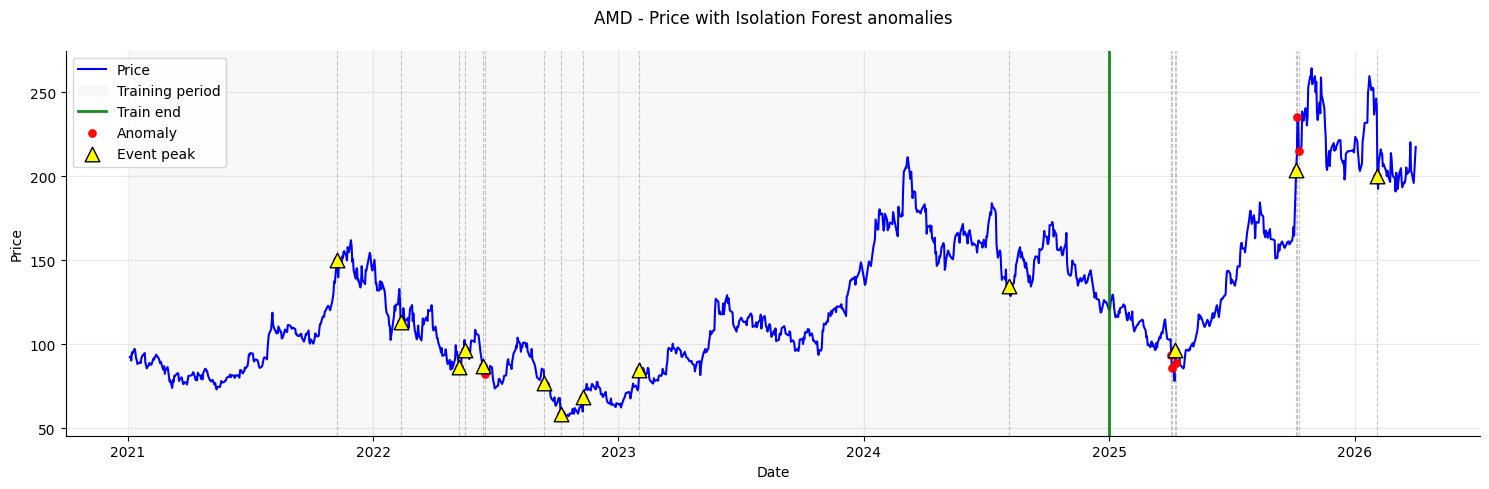

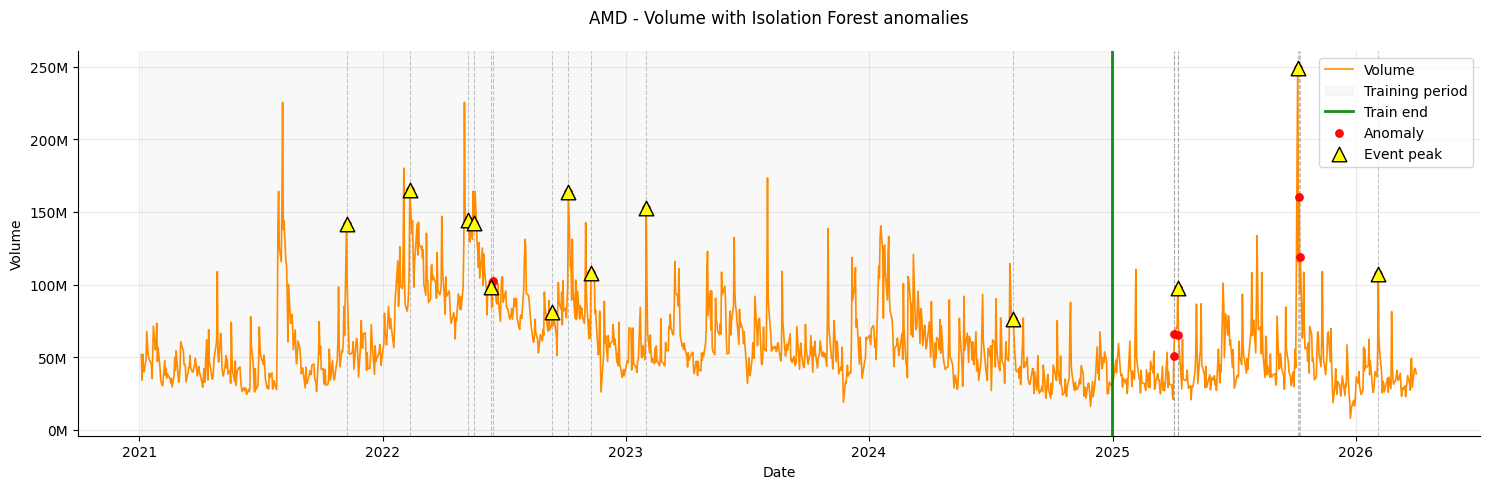

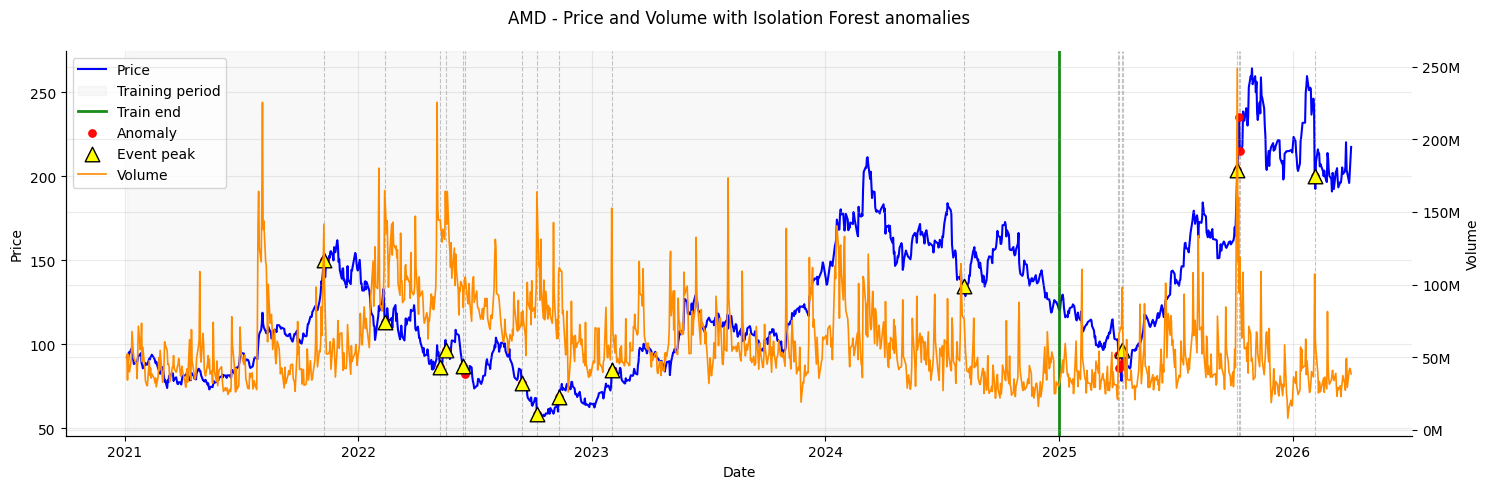

Series: HIMS


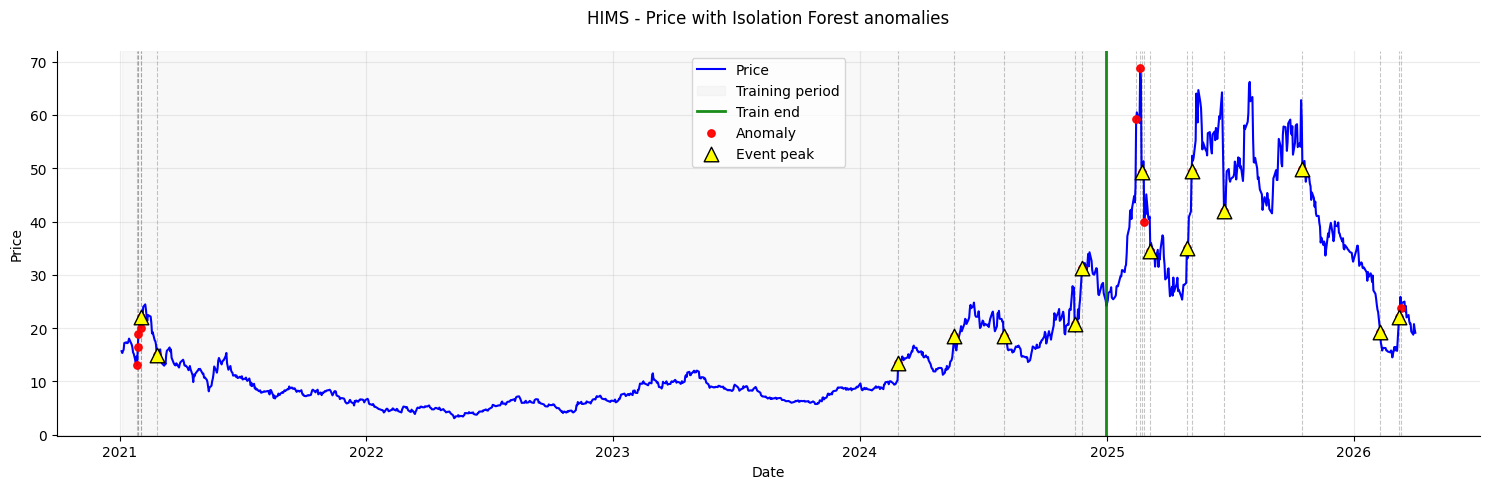

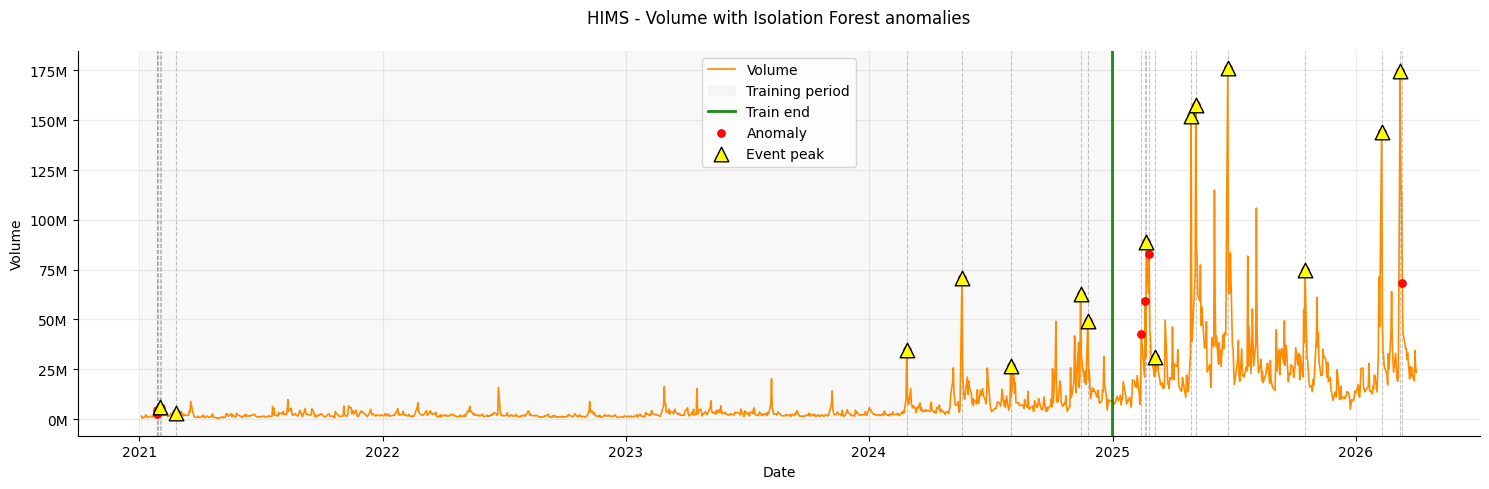

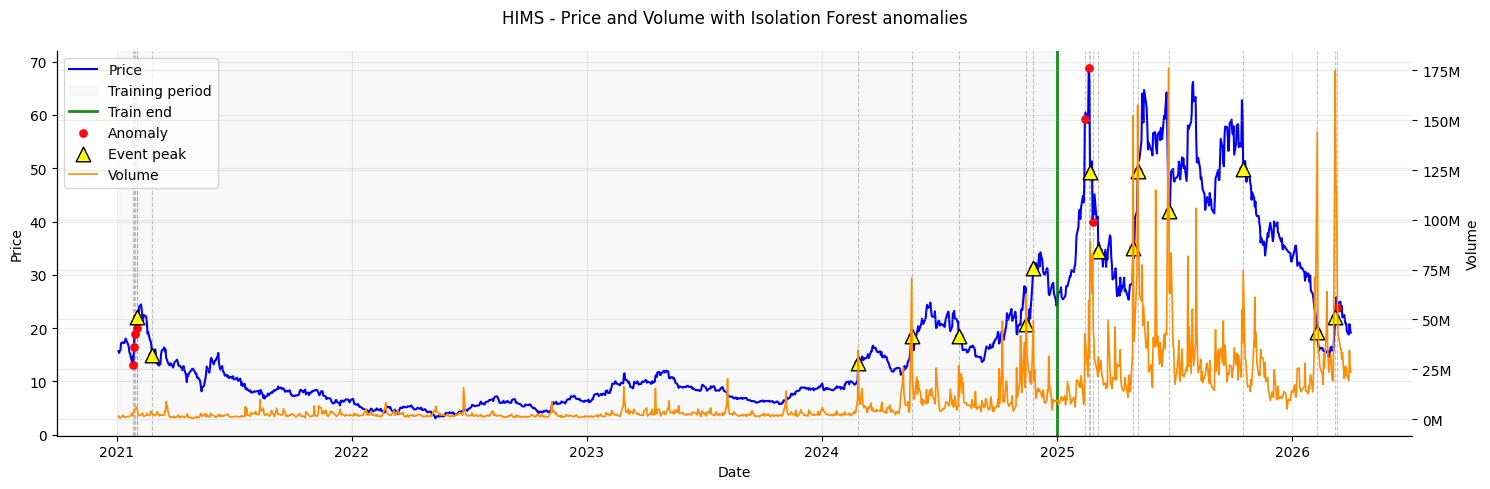

Series: ORCL


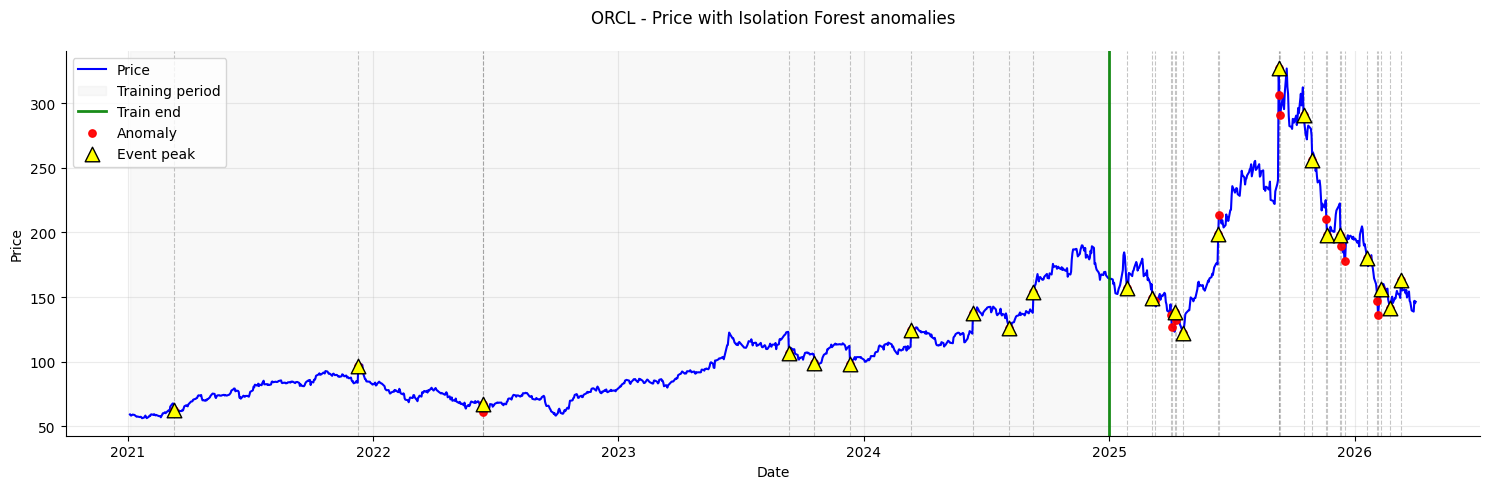

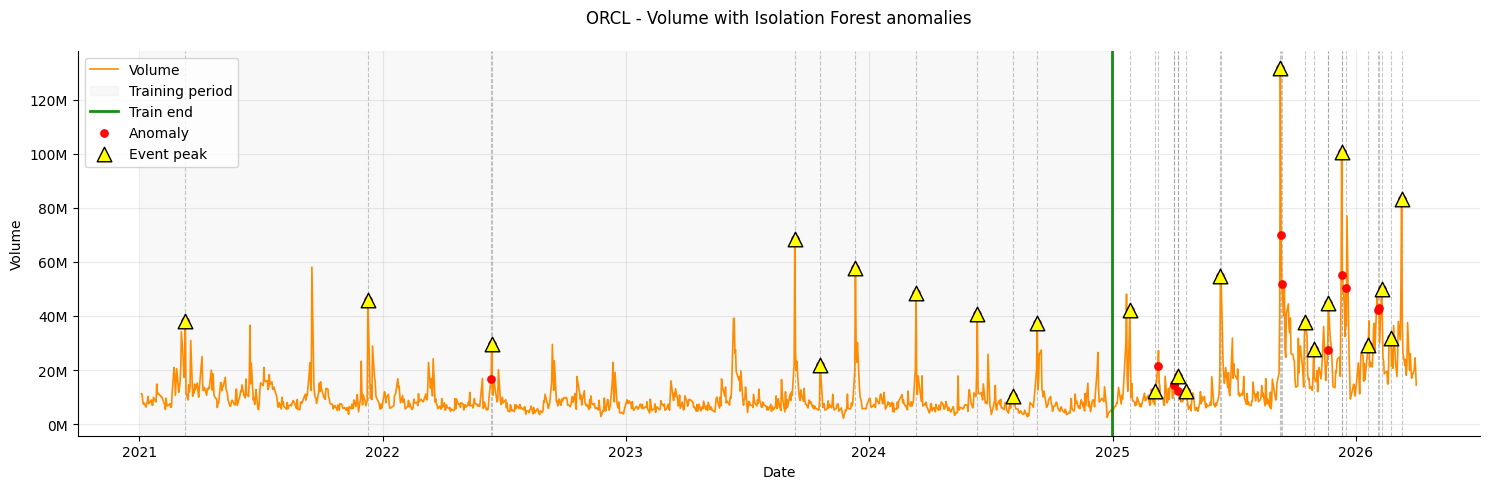

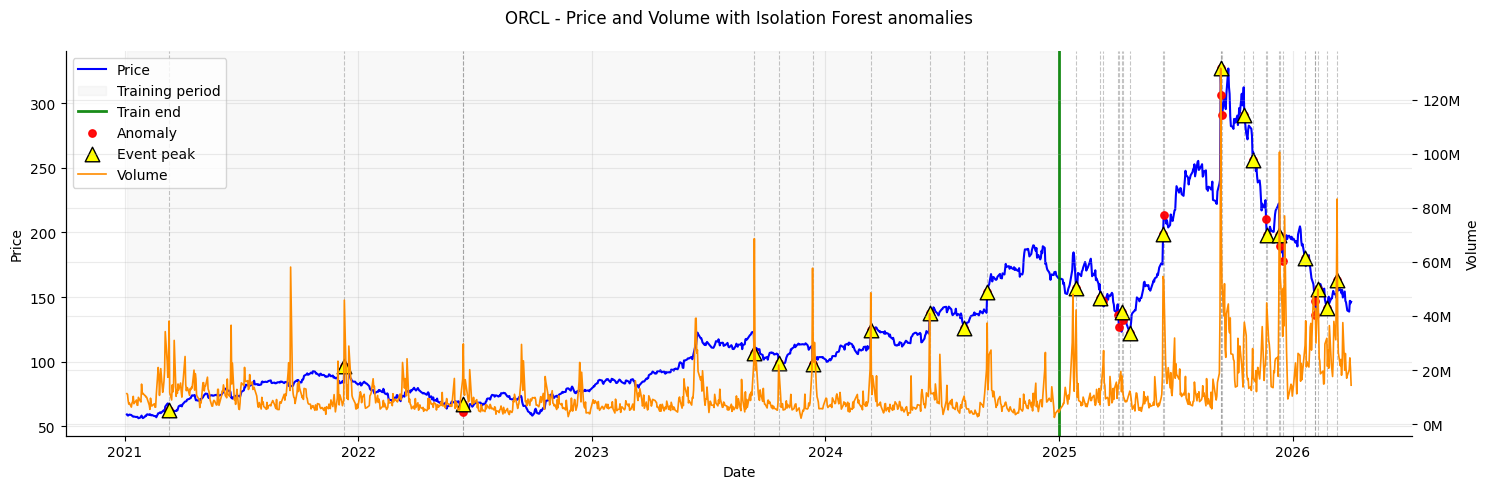

In [93]:
for s in STOCK_SERIES:
    print("=" * 100)
    print(f"Series: {s}")
    plot_price_volume_and_anomalies(s, analysis_df, volume_style=VOLUME_STYLE)


Series: AMD


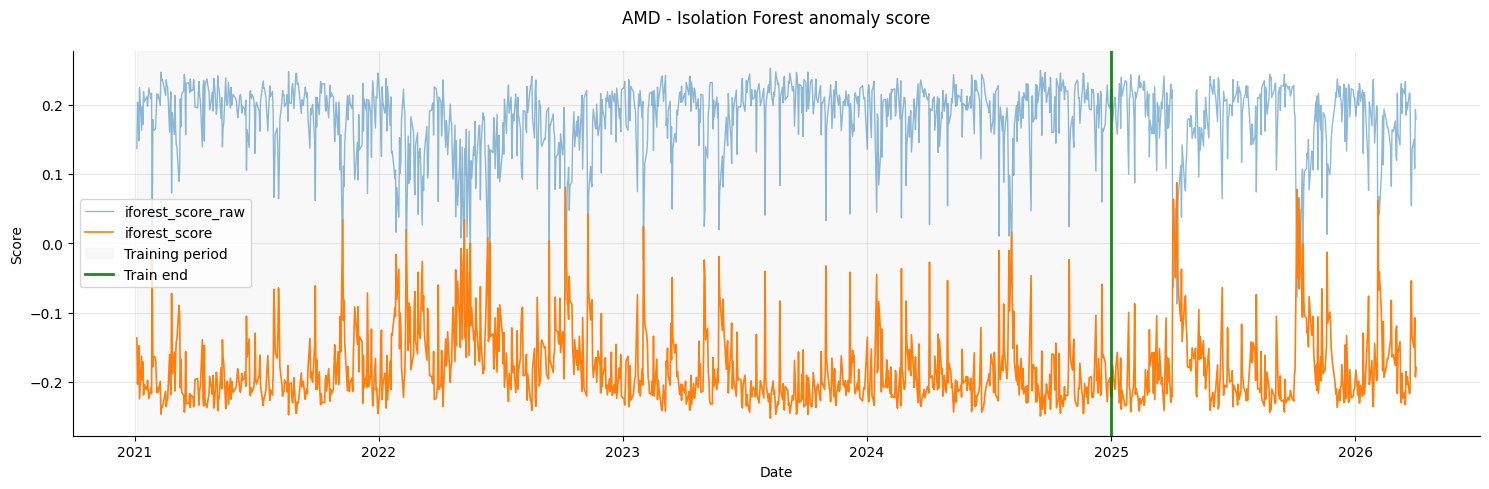

Series: HIMS


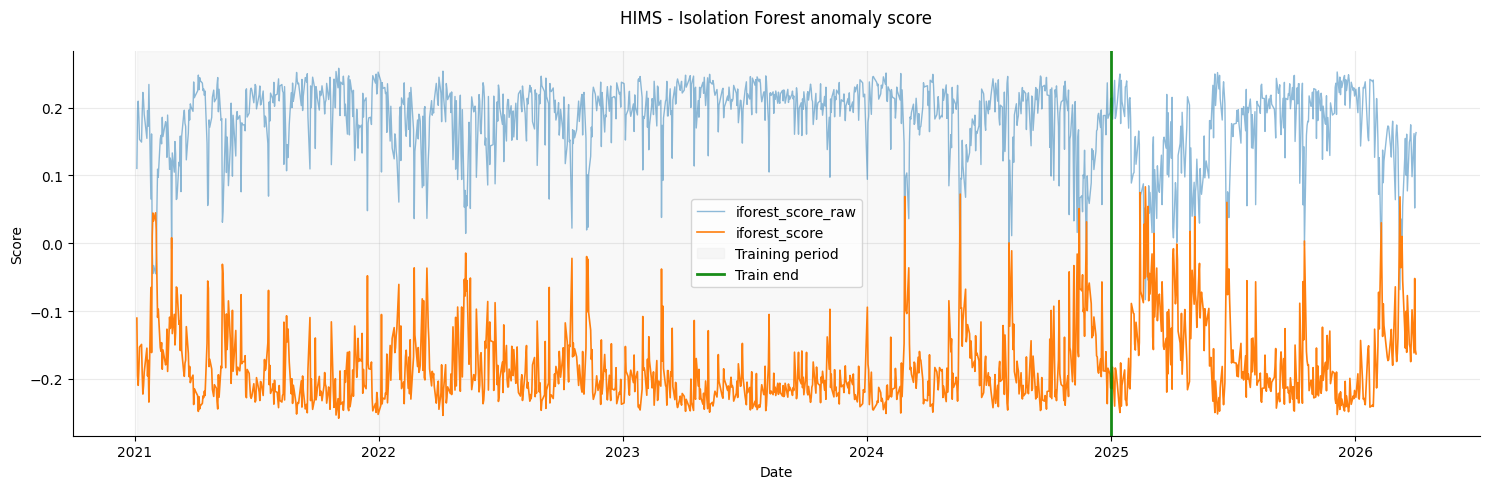

Series: ORCL


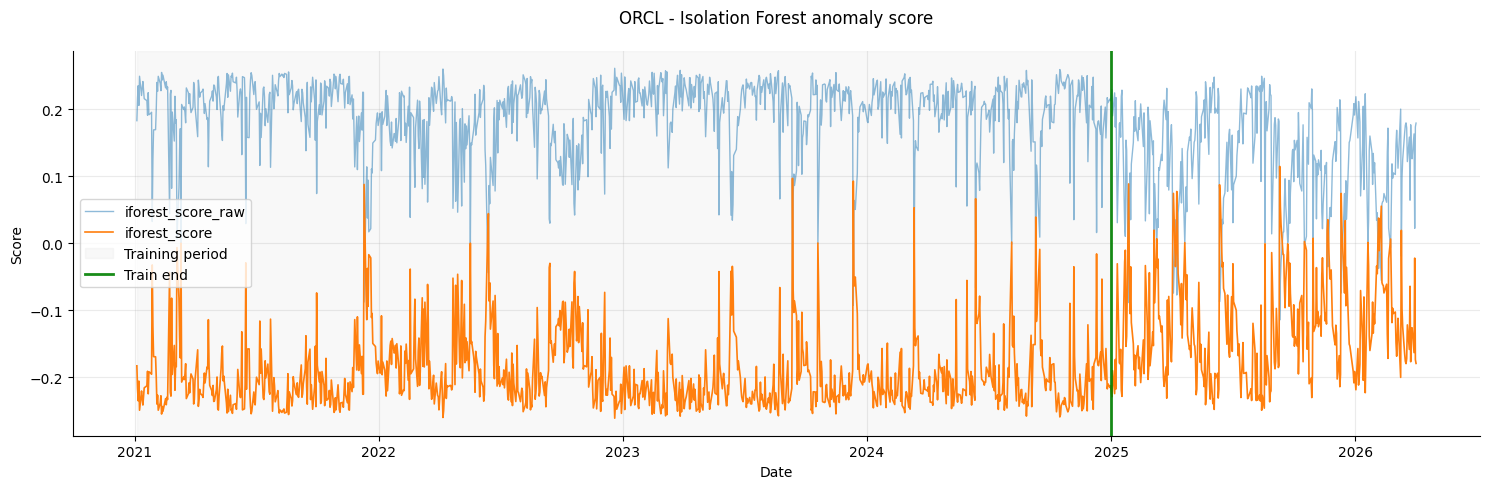

In [94]:
for s in STOCK_SERIES:
    print("=" * 100)
    print(f"Series: {s}")
    plot_score(s, analysis_df)


Series: AMD


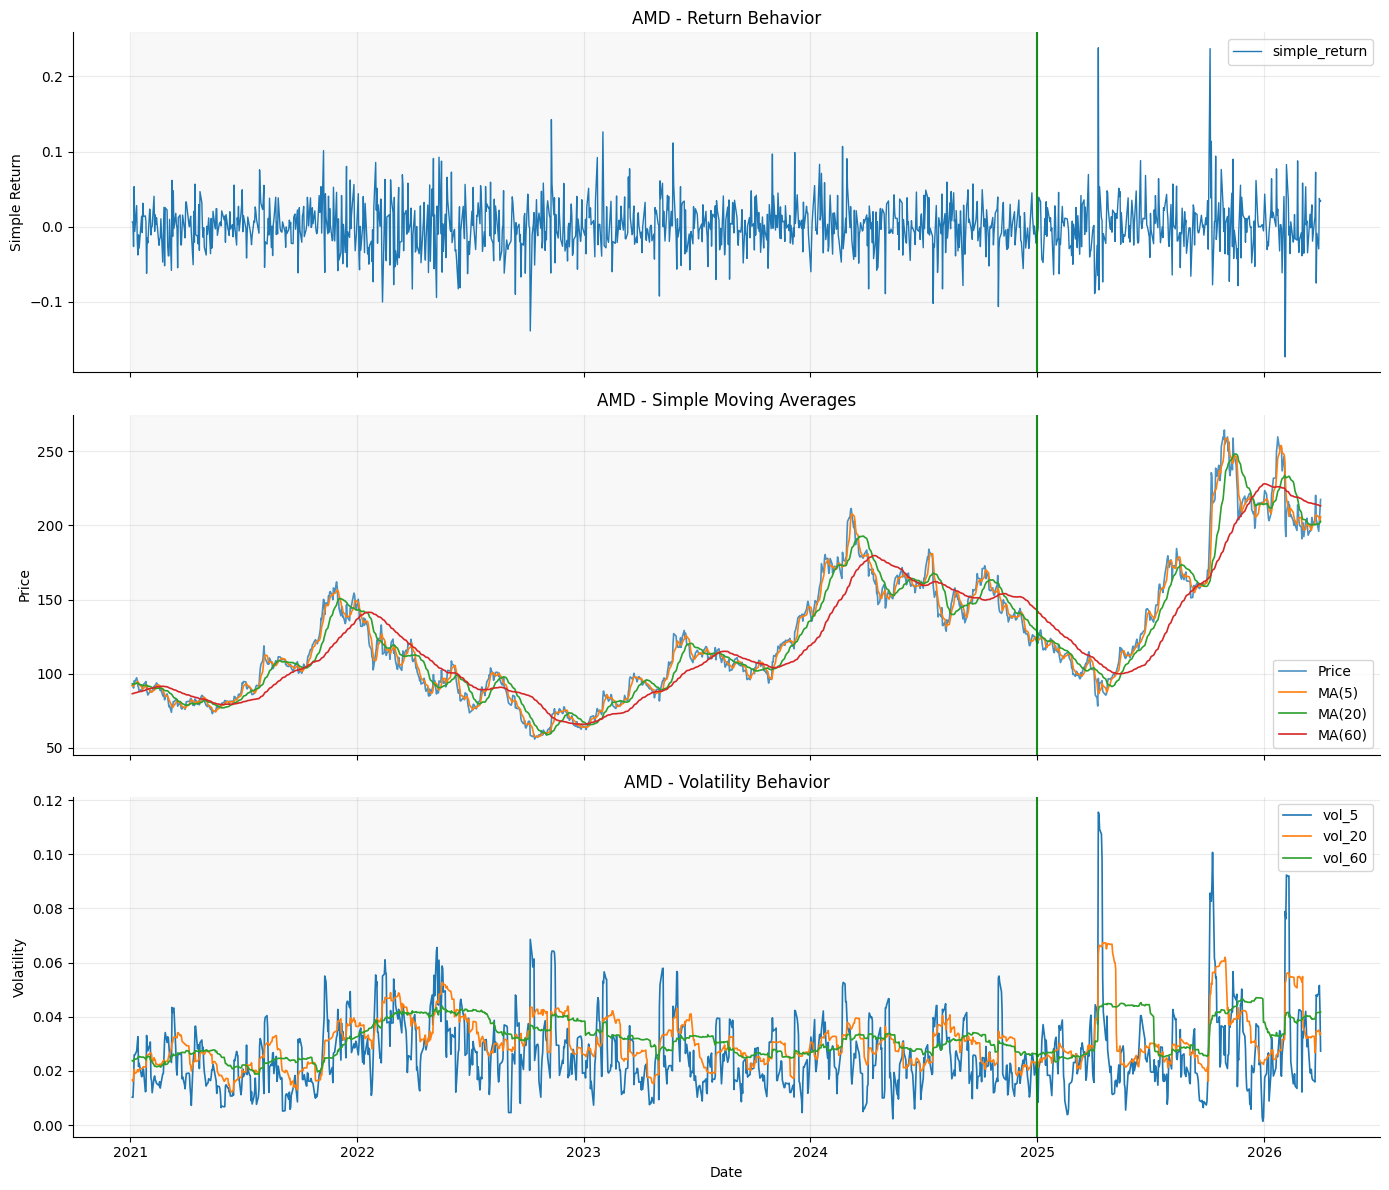

Series: HIMS


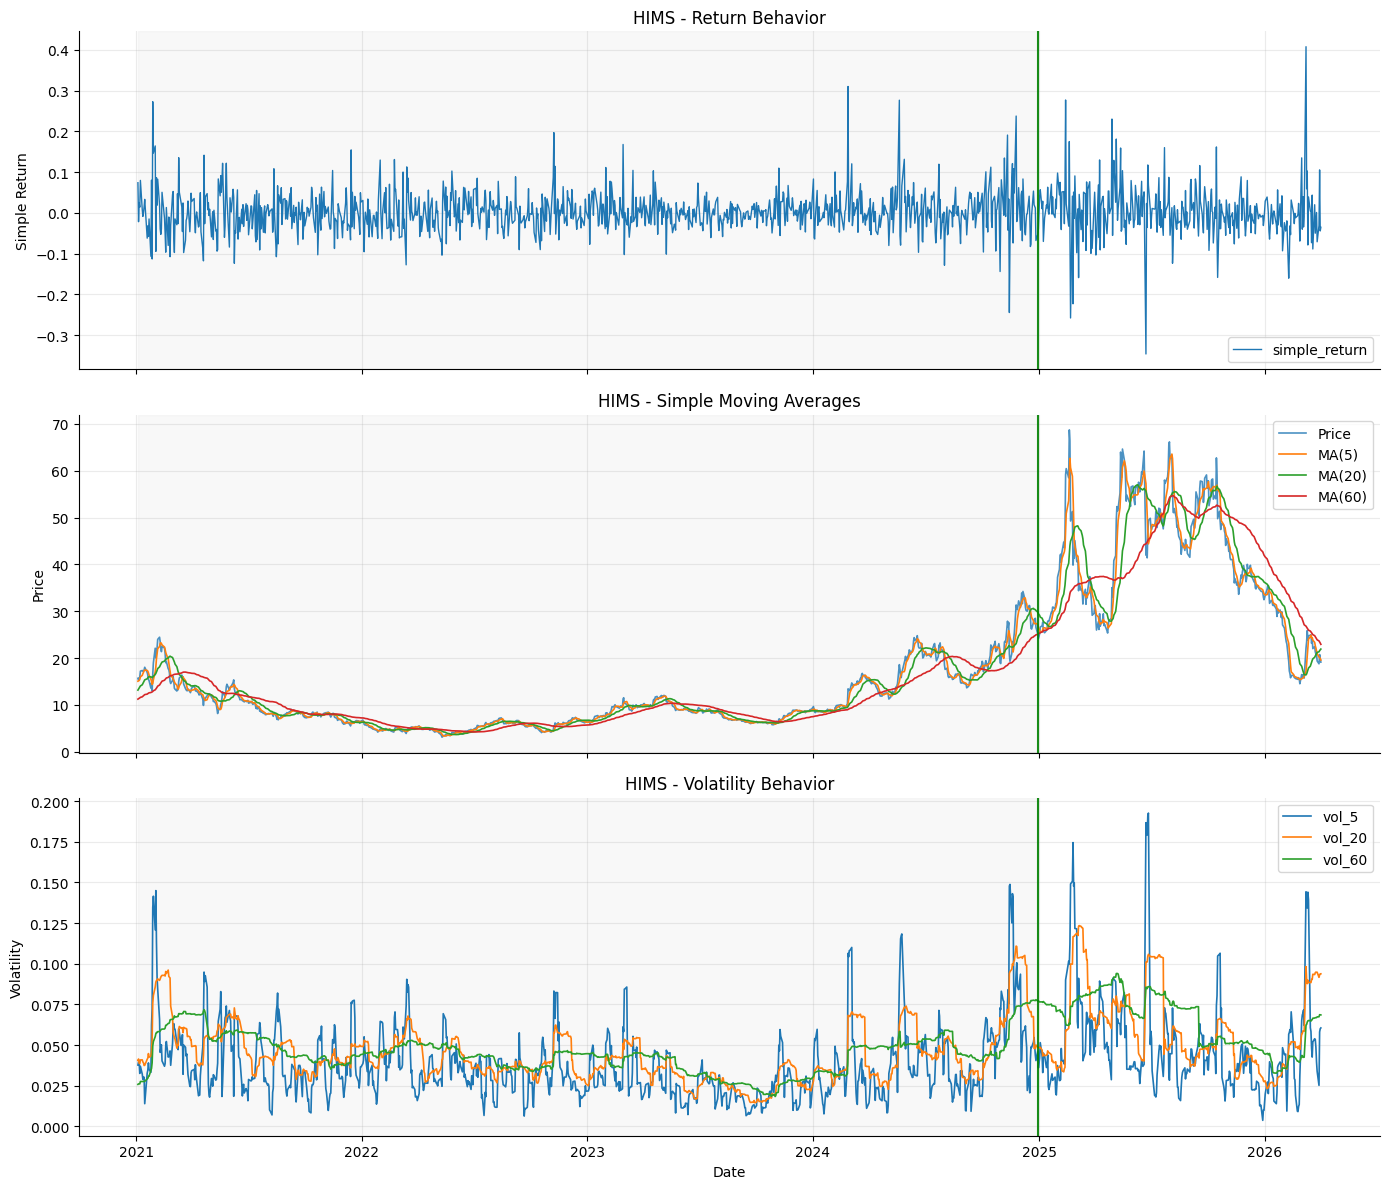

Series: ORCL


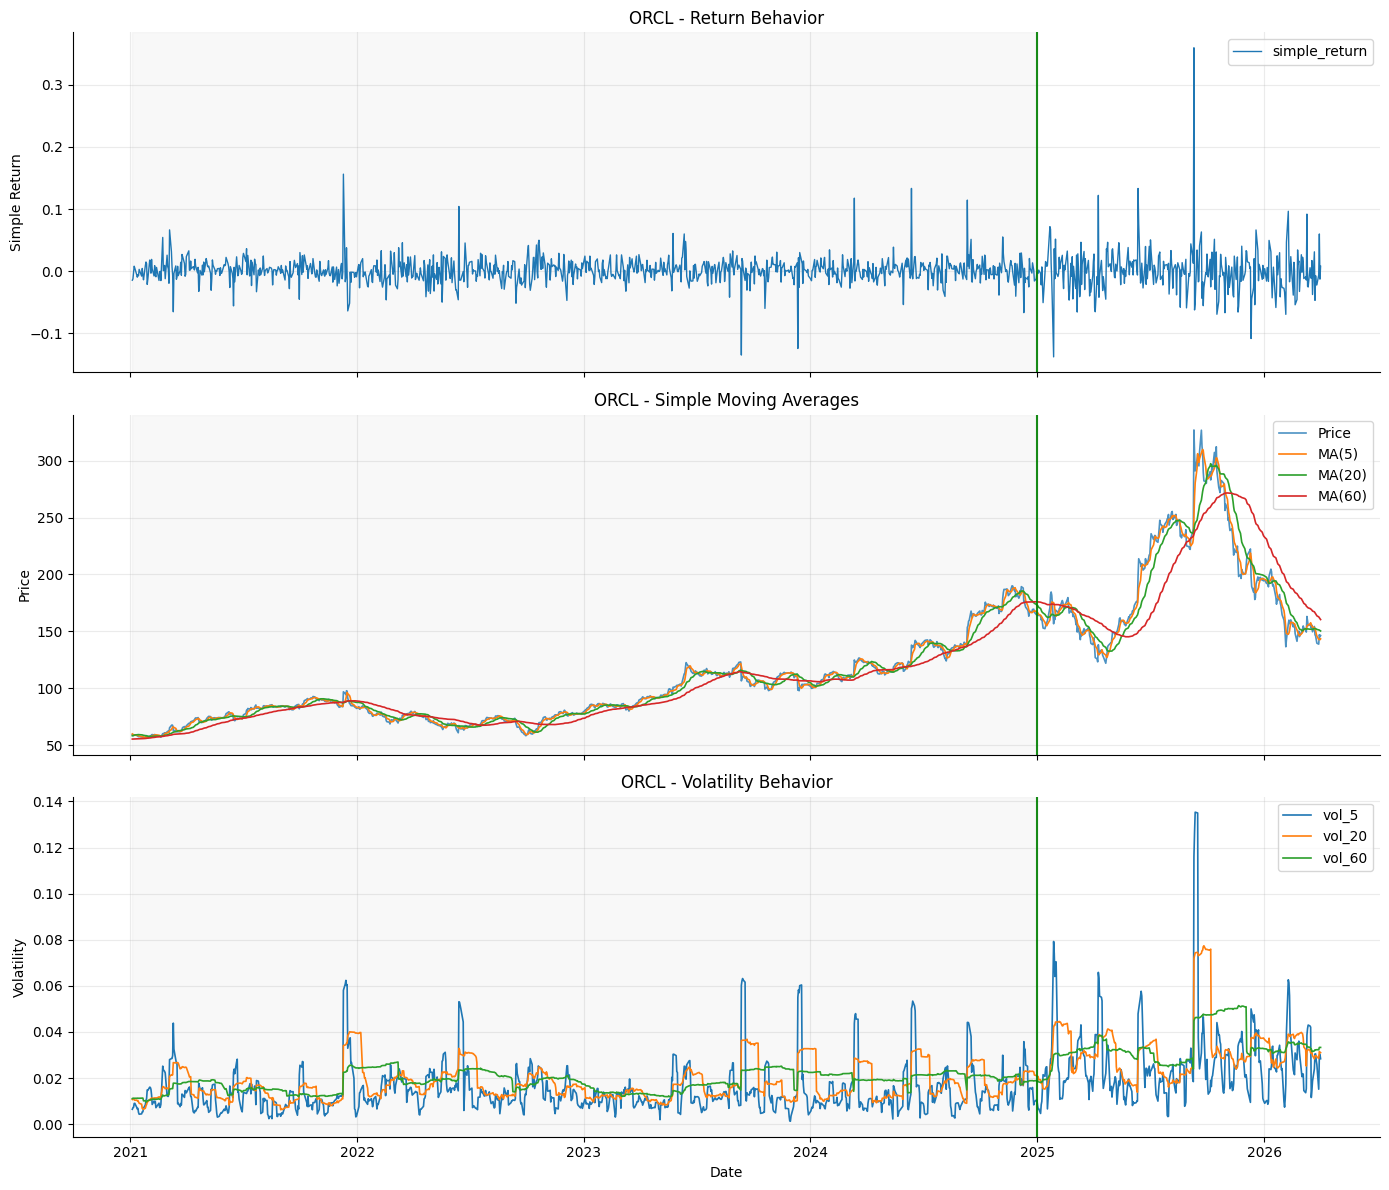

In [95]:
for s in STOCK_SERIES:
    print("=" * 100)
    print(f"Series: {s}")
    plot_selected_features(s, analysis_df)


## 13. Inspect anomaly tables for the selected stocks

In [96]:
for s in STOCK_SERIES:
    print("=" * 100)
    print(f"Series: {s}")
    show_anomaly_table(s, analysis_df, n=15)


Series: AMD


,Date,SeriesName,Ticker,Price,iforest_score_raw,iforest_score,iforest_is_event_peak,simple_return,return_5d,vol_20,volume_z_20
1071,2025-04-09,AMD,AMD,96.839996,-0.087496,0.087496,True,0.238205,-0.059441,0.063068,2.275477
444,2022-10-07,AMD,AMD,58.439999,-0.080747,0.080747,True,-0.138688,-0.077652,0.043478,3.060043
1194,2025-10-06,AMD,AMD,203.710007,-0.077678,0.077678,True,0.237080,0.262457,0.048188,3.692934
1196,2025-10-08,AMD,AMD,235.559998,-0.063862,0.063862,False,0.113706,0.436254,0.052383,2.024486
1068,2025-04-04,AMD,AMD,85.760002,-0.063202,0.063202,False,-0.085714,-0.169153,0.039169,2.412499
1277,2026-02-04,AMD,AMD,200.190002,-0.061259,0.061259,True,-0.173144,-0.207921,0.052635,2.759174
1198,2025-10-10,AMD,AMD,214.899994,-0.048399,0.048399,False,-0.077247,0.305034,0.056348,1.255237
468,2022-11-10,AMD,AMD,68.470001,-0.042218,0.042218,True,0.142690,0.139078,0.041990,1.335915
339,2022-05-09,AMD,AMD,86.360001,-0.034054,0.034054,True,-0.094189,-0.038735,0.045689,1.303393
214,2021-11-08,AMD,AMD,150.160004,-0.033591,0.033591,True,0.101364,0.199074,0.025458,2.720519


Series: HIMS


,Date,SeriesName,Ticker,Price,iforest_score_raw,iforest_score,iforest_is_event_peak,simple_return,return_5d,vol_20,volume_z_20
2356,2025-02-21,HIMS,HIMS,49.279999,-0.083104,0.083104,True,-0.257943,-0.167286,0.099830,2.287315
2351,2025-02-13,HIMS,HIMS,59.180000,-0.074554,0.074554,False,0.277082,0.462318,0.059255,2.630999
2167,2024-05-20,HIMS,HIMS,18.600000,-0.072329,0.072329,True,0.276596,0.442979,0.062407,2.795934
2109,2024-02-27,HIMS,HIMS,13.430000,-0.068865,0.068865,True,0.310244,0.397503,0.068239,3.603439
2617,2026-03-09,HIMS,HIMS,22.160000,-0.068317,0.068317,True,0.407878,0.344660,0.098222,2.690752
2439,2025-06-23,HIMS,HIMS,41.980000,-0.060184,0.060184,True,-0.346310,-0.243331,0.101039,2.862660
2358,2025-02-25,HIMS,HIMS,39.860001,-0.054281,0.054281,False,-0.223153,-0.318632,0.116600,1.701694
2291,2024-11-14,HIMS,HIMS,20.850000,-0.051114,0.051114,True,-0.244565,-0.117274,0.094002,2.010107
1337,2021-02-01,HIMS,HIMS,22.110001,-0.044849,0.044849,True,0.164297,0.628130,0.085786,2.090487
1335,2021-01-28,HIMS,HIMS,16.559999,-0.044596,0.044596,False,0.272867,0.073234,0.075920,2.538490


Series: ORCL


,Date,SeriesName,Ticker,Price,iforest_score_raw,iforest_score,iforest_is_event_peak,simple_return,return_5d,vol_20,volume_z_20
5130,2025-09-10,ORCL,ORCL,326.897064,-0.114707,0.114707,True,0.359488,0.469367,0.071894,3.372152
4630,2023-09-12,ORCL,ORCL,106.546776,-0.096883,0.096883,True,-0.134954,-0.115906,0.036197,3.246796
4694,2023-12-12,ORCL,ORCL,98.351288,-0.092698,0.092698,True,-0.124381,-0.119794,0.030712,3.346365
4974,2025-01-27,ORCL,ORCL,156.692215,-0.088543,0.088543,True,-0.137908,-0.017078,0.042079,2.075622
4191,2021-12-10,ORCL,ORCL,96.946457,-0.087725,0.087725,True,0.156134,0.163078,0.034066,3.238214
5069,2025-06-12,ORCL,ORCL,198.565826,-0.087387,0.087387,True,0.133122,0.167816,0.029728,3.525789
5025,2025-04-09,ORCL,ORCL,138.288696,-0.077280,0.077280,True,0.122008,-0.042301,0.038083,1.412703
5022,2025-04-04,ORCL,ORCL,126.983253,-0.074435,0.074435,False,-0.065292,-0.089444,0.030442,0.621771
5195,2025-12-11,ORCL,ORCL,198.325745,-0.074323,0.074323,True,-0.108336,-0.072225,0.037421,2.966741
5070,2025-06-13,ORCL,ORCL,213.826370,-0.070391,0.070391,False,0.076854,0.236754,0.031820,2.645676


## 14. Review the selected indices

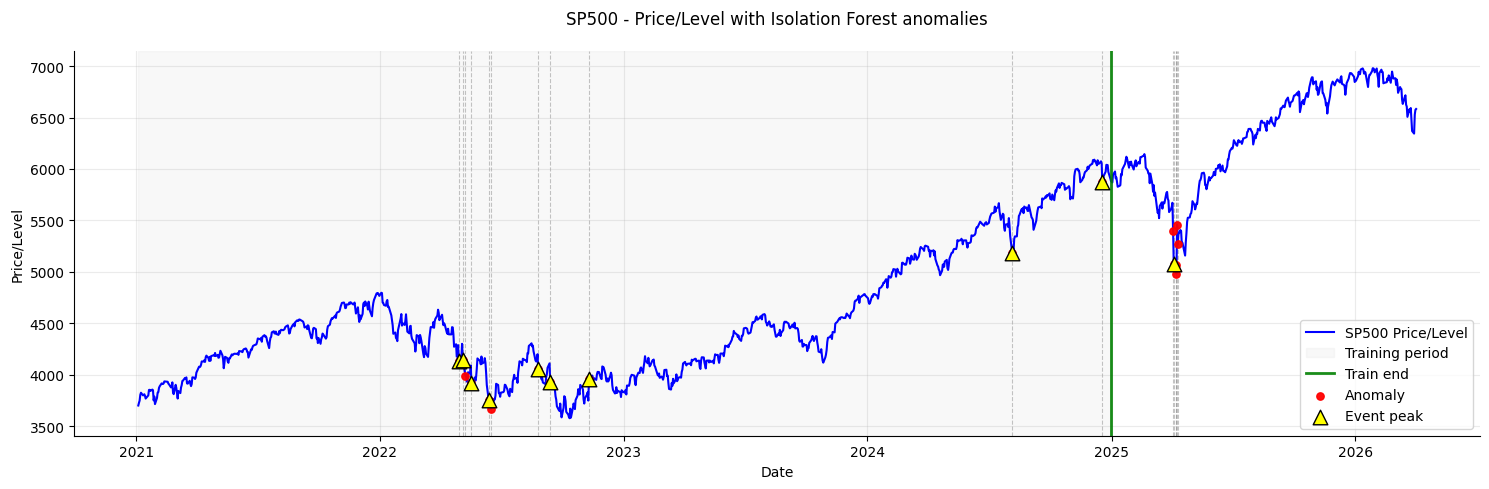

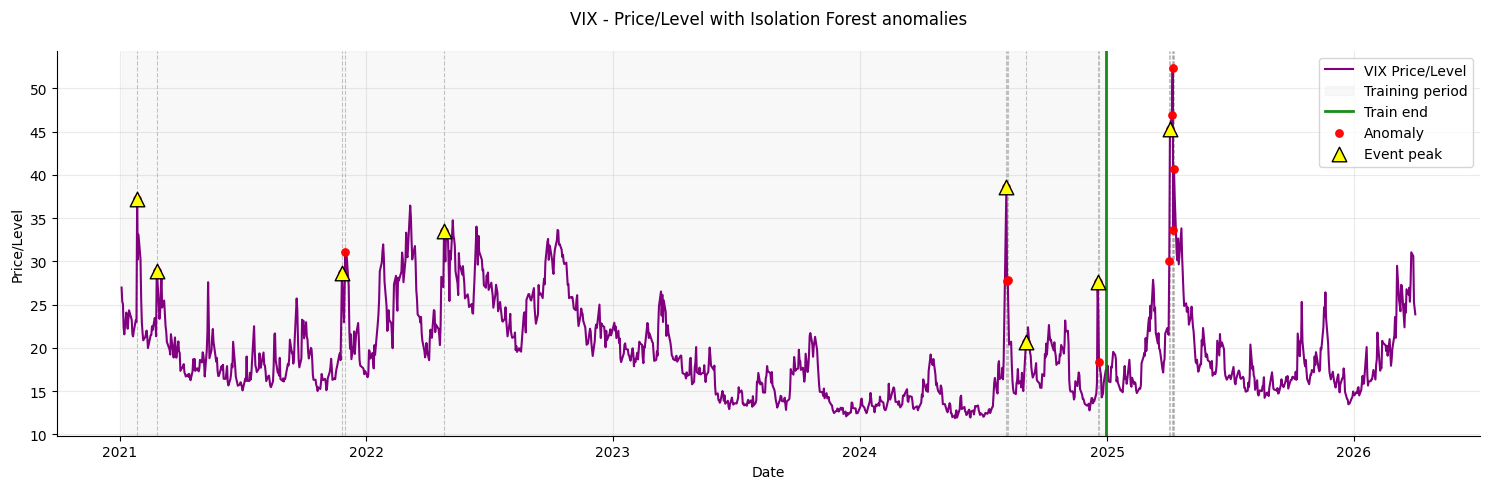

In [97]:
plot_market_context_with_anomalies(analysis_df)


## 15. Compare anomaly counts across the selected series

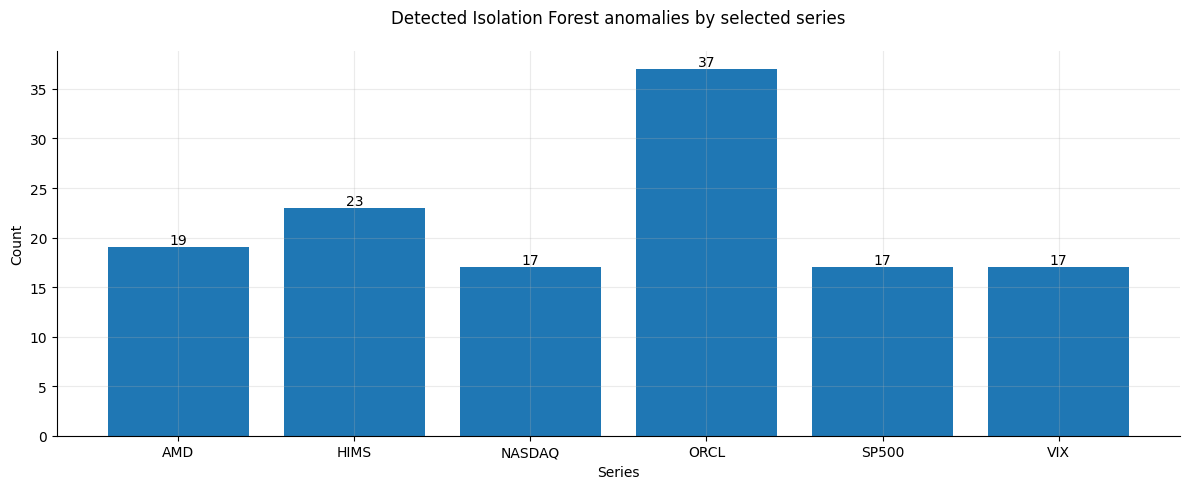

In [98]:
plot_df = summary_df.copy()

plt.figure(figsize=(12, 5))
bars = plt.bar(plot_df["SeriesName"], plot_df["n_anomalies_detected"])
plt.title("Detected Isolation Forest anomalies by selected series", pad=20)
plt.xlabel("Series")
plt.ylabel("Count")

for bar, value in zip(bars, plot_df["n_anomalies_detected"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


## 16. Notes 

- the same selected-universe idea
- the same event-peak concept
- similar anomaly terminology
- similar chart structure

Interpretation:
- `n_anomalies_detected` = raw anomaly dates flagged by Isolation Forest
- `n_event_peaks_detected` = clustered representative anomaly dates
- event peaks summarize nearby anomaly dates into one event
